In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dataset = pd.read_csv('../Data/final_dataset/final_dataset.csv')
print("Dataset rows: ", dataset.shape[0])
print("Dataset columns: ", dataset.shape[1])
dataset = dataset.iloc[:, [0, 4, 1, 2, 3]]
print("Dataset columns names: ", dataset.columns.tolist())

Dataset rows:  15265
Dataset columns:  6
Dataset columns names:  ['question', 'answer_index', 'answer', 'question_type', 'dimension']


In [5]:
dataset.describe()

,answer_index
count,15265.000000
mean,0.668261
std,0.993232
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,3.000000


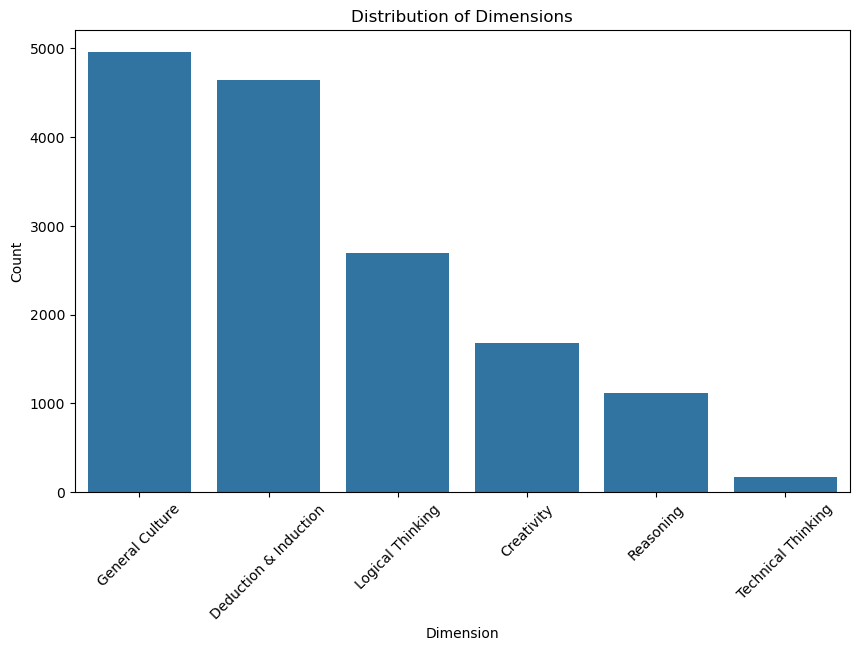

In [6]:
# dimensions distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='dimension', y='count', data=dataset['dimension'].value_counts().reset_index(name='count').rename(columns={'index': 'dimension'}))
plt.title('Distribution of Dimensions')
plt.xlabel('Dimension')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

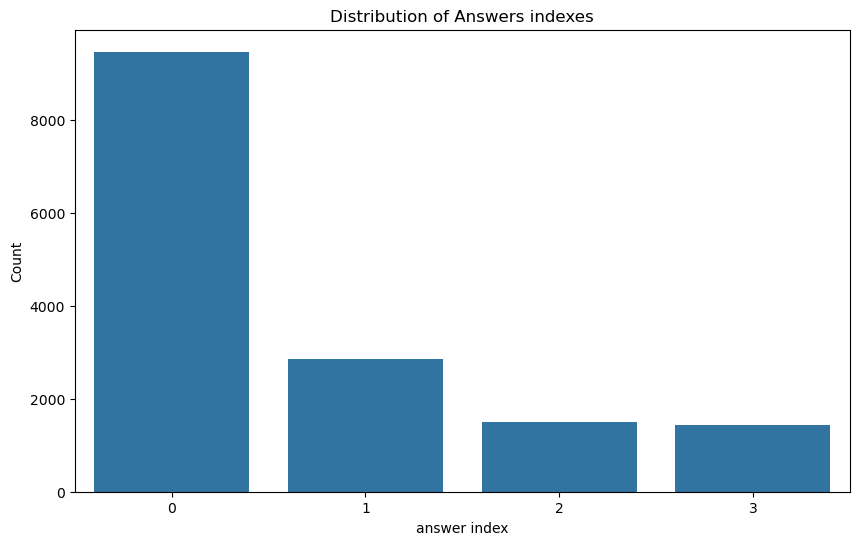

In [7]:
# dimensions distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='answer_index', y='count', data=dataset['answer_index'].value_counts().reset_index(name='count'))
plt.title('Distribution of Answers indexes')
plt.xlabel('answer index')
plt.ylabel('Count')
plt.show()

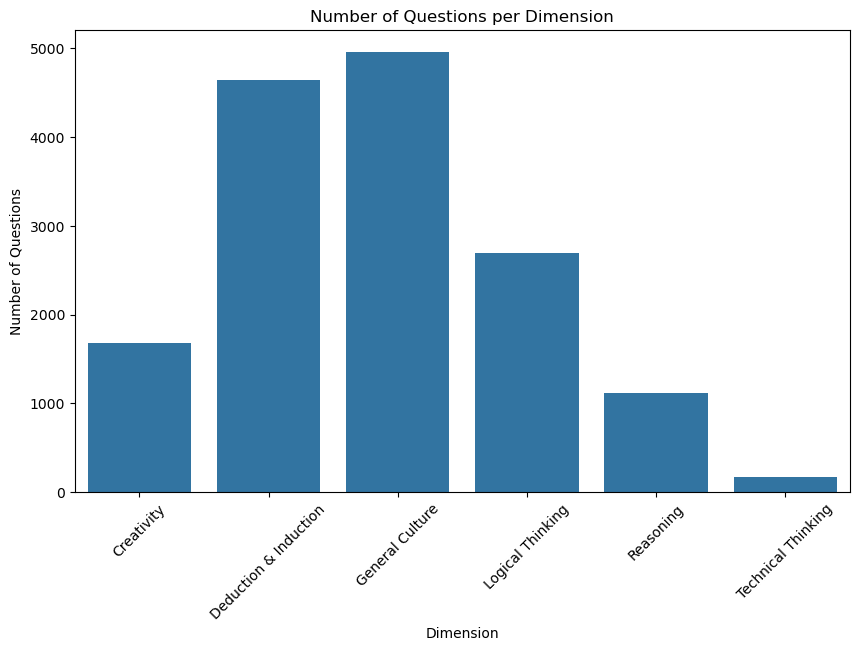

In [8]:
questions_per_dimension = dataset.groupby('dimension').size().reset_index(name='count')
plt.figure(figsize=(10, 6))
sns.barplot(x='dimension', y='count', data=questions_per_dimension)
plt.title('Number of Questions per Dimension')
plt.xlabel('Dimension')
plt.ylabel('Number of Questions')
plt.xticks(rotation=45)
plt.show()

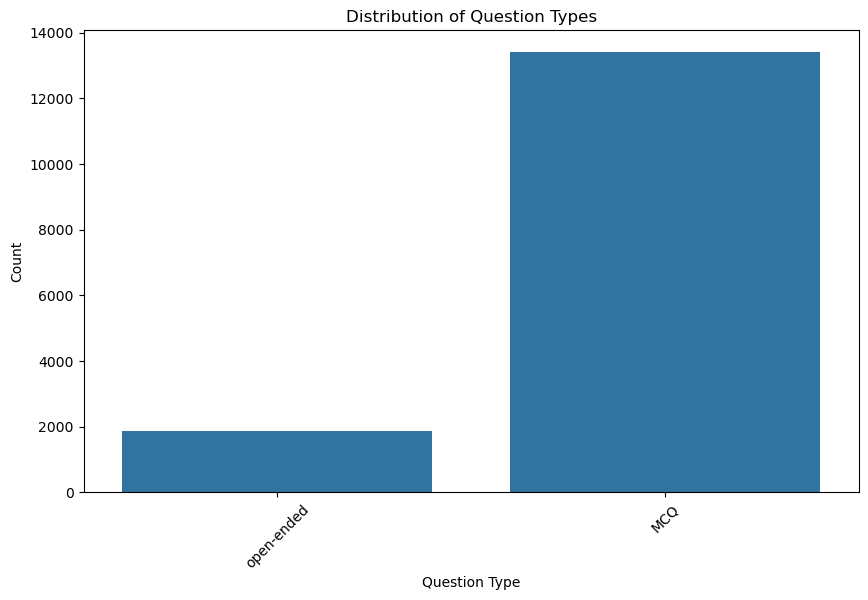

In [9]:
# Visualizing the distribution of question types
plt.figure(figsize=(10, 6))
sns.countplot(x='question_type', data=dataset)
plt.title('Distribution of Question Types')
plt.xlabel('Question Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

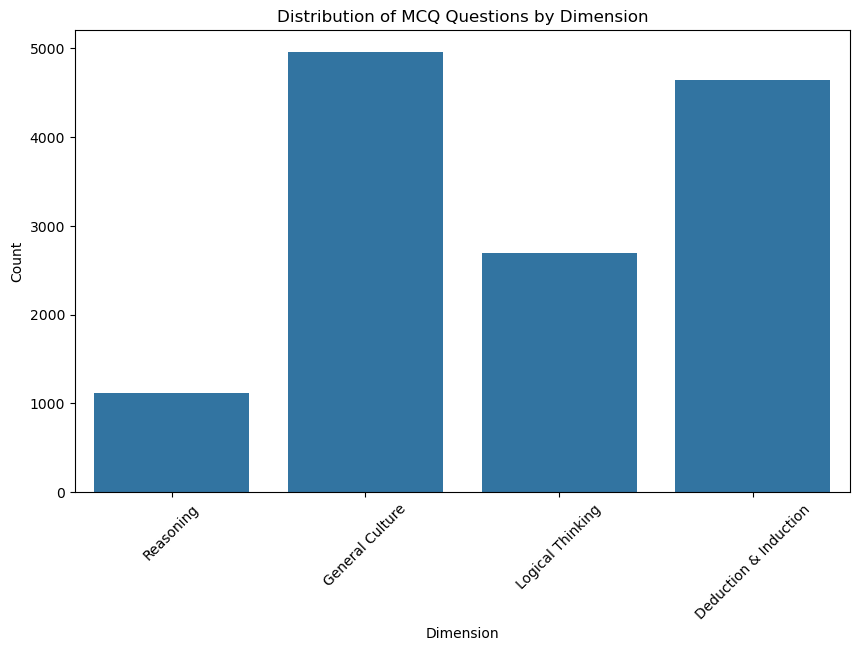

In [10]:
# MCQ questions dimensions
mcq_questions = dataset[dataset['question_type'] == 'MCQ']
plt.figure(figsize=(10, 6))
sns.countplot(x='dimension', data=mcq_questions)
plt.title('Distribution of MCQ Questions by Dimension')
plt.xlabel('Dimension')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

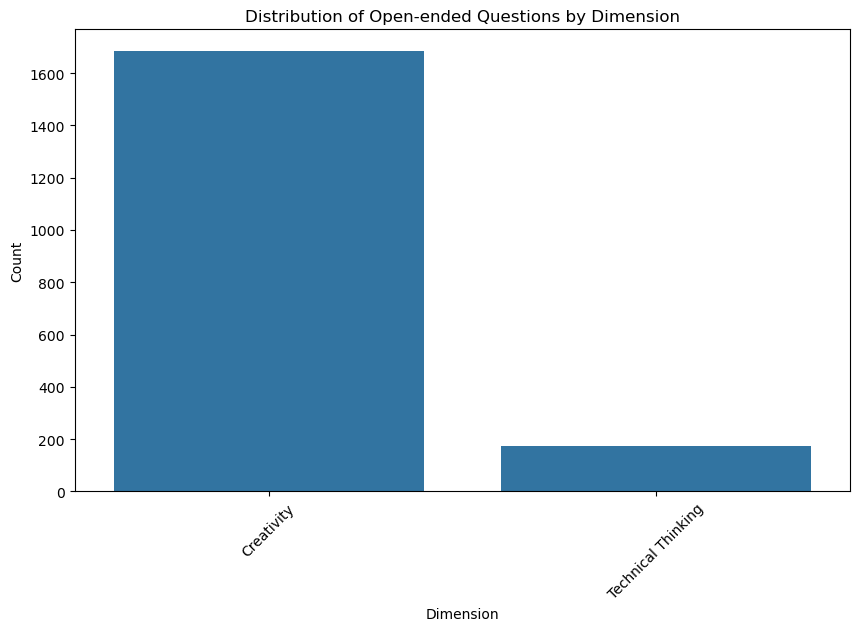

In [11]:
# open-ended questions dimensions
open_ended_questions = dataset[dataset['question_type'] == 'open-ended']
plt.figure(figsize=(10, 6))
sns.countplot(x='dimension', data=open_ended_questions)
plt.title('Distribution of Open-ended Questions by Dimension')
plt.xlabel('Dimension')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

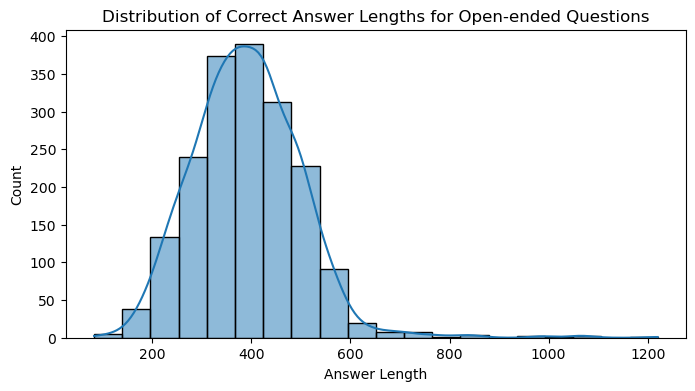

In [13]:
# correct answers length for the open-ended questions
answer_lengths =open_ended_questions["answer"].str.len()
plt.figure(figsize=(8, 4))
sns.histplot(x=answer_lengths, bins=20, kde=True)
plt.title('Distribution of Correct Answer Lengths for Open-ended Questions')
plt.xlabel('Answer Length')
plt.show()